# Task 6: Colorization of Historical Photographs

**Project:** Extension of Real-Time Image Colorization (Training Project)  
**New Features Added:**
- Fine-tuning the base colorization model specifically on historical-style photos
- Film artifact augmentation (grain noise, vignetting, slight desaturation) to simulate old photos
- Direct comparison: baseline model vs fine-tuned model on the same test images
- Focus on historical color accuracy rather than vivid/modern colorization

**Dataset:** Image Colorization Dataset (Kaggle, numpy arrays) — used as the base photo set, augmented with simulated historical artifacts to create a historical-style training set

## Step 1: Install Dependencies

In [1]:
!pip install torch torchvision --quiet
!pip install opencv-python-headless --quiet
!pip install scikit-image --quiet
!pip install matplotlib tqdm kaggle --quiet
print('All dependencies installed!')

All dependencies installed!


## Step 2: Imports

In [2]:
import os, cv2, json, time, random, shutil, zipfile, glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from skimage import color
from skimage.metrics import structural_similarity as ssim

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## Step 3: Download Dataset

In [3]:
KAGGLE_TOKEN = 'KGAT_2c7fc2df2c047f91c9b97fd55e5fda03'  # paste your token

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write(KAGGLE_TOKEN)
os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)

os.makedirs('hist_data', exist_ok=True)

if not os.path.exists('hist_data/l'):
    print('Downloading dataset...')
    !KAGGLE_API_TOKEN=$KAGGLE_TOKEN kaggle datasets download -d shravankumar9892/image-colorization -p hist_data
    print('Extracting...')
    for z in glob.glob('hist_data/*.zip'):
        with zipfile.ZipFile(z, 'r') as zf:
            zf.extractall('hist_data/')
    print('Done!')
else:
    print('Dataset already exists.')

Dataset URL: https://www.kaggle.com/datasets/shravankumar9892/image-colorization
License(s): CC0-1.0
100% 2.10G/2.10G [01:40<00:00, 22.5MB/s]

Extracting...
Done!


In [4]:
print('Loading numpy arrays...')
L_data  = np.load('hist_data/l/gray_scale.npy')
ab1     = np.load('hist_data/ab/ab/ab1.npy')
ab2     = np.load('hist_data/ab/ab/ab2.npy')
ab3     = np.load('hist_data/ab/ab/ab3.npy')
ab_data = np.concatenate([ab1, ab2, ab3], axis=0)

min_len = min(len(L_data), len(ab_data))
L_data  = L_data[:min_len]
ab_data = ab_data[:min_len]

MAX_SAMPLES = 3000
L_data  = L_data[:MAX_SAMPLES]
ab_data = ab_data[:MAX_SAMPLES]

print(f'Using {len(L_data)} samples')
print(f'L range:  {L_data.min():.2f} to {L_data.max():.2f}')
print(f'ab range: {ab_data.min():.2f} to {ab_data.max():.2f}')

Loading numpy arrays...
Using 3000 samples
L range:  0.00 to 255.00
ab range: 20.00 to 226.00


## Step 4: Historical Artifact Augmentation

Simulates old-photo characteristics so the fine-tuned model learns
to handle grain, vignetting, and faded color typical of historical photos.

/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 26778 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


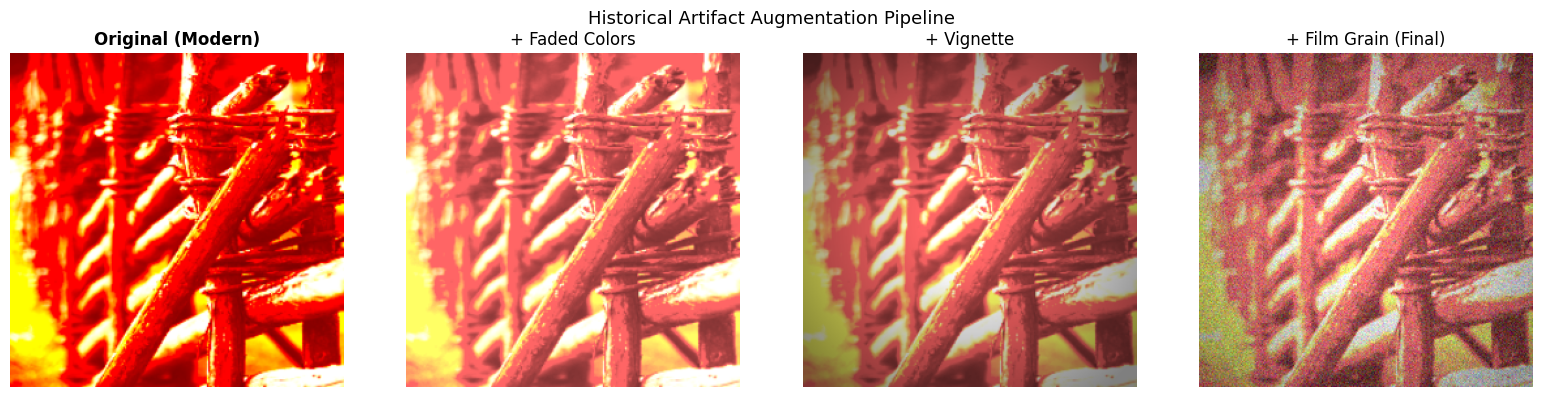

Augmentation demo saved!


In [5]:
def add_film_grain(img, intensity=15):
    """Add random grain noise to simulate old film"""
    noise = np.random.normal(0, intensity, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


def add_vignette(img, strength=0.6):
    """Add dark vignette around edges, typical of old cameras"""
    H, W = img.shape[:2]
    X, Y = np.meshgrid(np.linspace(-1,1,W), np.linspace(-1,1,H))
    radius   = np.sqrt(X**2 + Y**2)
    mask     = 1 - strength * np.clip(radius - 0.3, 0, 1)
    mask     = np.clip(mask, 0, 1)
    vignette = img.astype(np.float32) * mask[:,:,None]
    return np.clip(vignette, 0, 255).astype(np.uint8)


def fade_colors(img, fade_amt=0.4):
    """Reduce saturation to simulate faded historical colors"""
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[:,:,1] = hsv[:,:,1] * (1 - fade_amt)
    hsv = np.clip(hsv, 0, 255).astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)


def apply_historical_artifacts(img):
    """Combine all three effects for historical look"""
    img = fade_colors(img, fade_amt=random.uniform(0.2, 0.5))
    img = add_vignette(img, strength=random.uniform(0.3, 0.6))
    img = add_film_grain(img, intensity=random.uniform(8, 20))
    return img


def lab_to_rgb_raw(L_np, ab_np):
    if L_np.ndim == 3: L_np = L_np[:,:,0]
    if ab_np.ndim == 3 and ab_np.shape[0] == 2: ab_np = ab_np.transpose(1,2,0)
    lab = np.stack([L_np, ab_np[:,:,0], ab_np[:,:,1]], axis=2).astype(np.float32)
    return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


# Demo the augmentation
demo_idx = random.randint(0, len(L_data)-1)
demo_rgb = lab_to_rgb_raw(L_data[demo_idx], ab_data[demo_idx])
demo_rgb = cv2.resize(demo_rgb, (256, 256))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(demo_rgb); axes[0].set_title('Original (Modern)', fontweight='bold')
axes[1].imshow(fade_colors(demo_rgb, 0.4)); axes[1].set_title('+ Faded Colors')
axes[2].imshow(add_vignette(fade_colors(demo_rgb, 0.4), 0.5)); axes[2].set_title('+ Vignette')
axes[3].imshow(apply_historical_artifacts(demo_rgb)); axes[3].set_title('+ Film Grain (Final)')
for ax in axes: ax.axis('off')
plt.suptitle('Historical Artifact Augmentation Pipeline', fontsize=13)
plt.tight_layout()
plt.savefig('artifact_augmentation_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Augmentation demo saved!')

## Step 5: Colorization U-Net (Base Architecture)

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class ColorizationUNet(nn.Module):
    """
    Base colorization U-Net (same architecture as training project).
    Input:  [B, 1, H, W] — L channel only
    Output: [B, 2, H, W] — ab channels
    """
    def __init__(self):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.enc1 = DoubleConv(1, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.bottleneck = DoubleConv(512, 1024)
        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        self.out_conv = nn.Conv2d(64, 2, 1)
        self.tanh     = nn.Tanh()

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.tanh(self.out_conv(d1))


# Two model instances: baseline (untouched) and fine-tuned
baseline_model  = ColorizationUNet().to(device)
finetuned_model = ColorizationUNet().to(device)
finetuned_model.load_state_dict(baseline_model.state_dict())  # start identical

print(f'Total params: {sum(p.numel() for p in baseline_model.parameters()):,}')
print('Baseline and fine-tune models initialized identically.')

Total params: 31,042,434
Baseline and fine-tune models initialized identically.


## Step 6: Dataset (Original + Historical-Augmented Pairs)

In [7]:
class HistoricalFineTuneDataset(Dataset):
    """
    For fine-tuning: input is a historically-augmented grayscale image,
    target is the original (clean) ab channels — model learns to
    colorize historical-looking photos correctly despite grain/fade/vignette.
    """
    def __init__(self, L_arr, ab_arr, size=256, apply_augment=True):
        self.L_arr  = L_arr
        self.ab_arr = ab_arr
        self.size   = size
        self.apply_augment = apply_augment
        print(f'Dataset: {len(L_arr)} samples (augment={apply_augment})')

    def __len__(self): return len(self.L_arr)

    def __getitem__(self, idx):
        L_np  = self.L_arr[idx].copy()
        ab_np = self.ab_arr[idx].copy()
        if L_np.ndim == 3: L_np = L_np[:,:,0]
        if ab_np.ndim == 3 and ab_np.shape[0] == 2: ab_np = ab_np.transpose(1,2,0)

        L_np  = cv2.resize(L_np.astype(np.float32),  (self.size, self.size))
        ab_np = cv2.resize(ab_np.astype(np.float32), (self.size, self.size))

        # Build RGB for augmentation
        rgb = lab_to_rgb_raw(L_np, ab_np)

        if self.apply_augment:
            rgb_aug = apply_historical_artifacts(rgb)
            aug_lab = color.rgb2lab(rgb_aug.astype(np.float32)/255.0)
            L_input = aug_lab[:,:,0]  # grain/vignette affects L too
        else:
            L_input = L_np

        L_max  = 100.0 if L_input.max() > 1.0 else 1.0
        ab_max = 128.0 if np.abs(ab_np).max() > 1.0 else 1.0

        L  = torch.FloatTensor(L_input).unsqueeze(0) / (L_max/2.0) - 1.0
        ab = torch.FloatTensor(ab_np).permute(2,0,1) / ab_max

        return L, ab


n       = len(L_data)
indices = list(range(n))
random.shuffle(indices)
split   = int(0.8 * n)

train_set = HistoricalFineTuneDataset(L_data[indices[:split]],  ab_data[indices[:split]],  apply_augment=True)
val_set   = HistoricalFineTuneDataset(L_data[indices[split:]], ab_data[indices[split:]], apply_augment=True)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train: {len(train_set)} | Val: {len(val_set)}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Dataset: 2400 samples (augment=True)
Dataset: 600 samples (augment=True)
Train: 2400 | Val: 600
Train batches: 300 | Val batches: 75


## Step 7: Training Setup

In [8]:
criterion = nn.SmoothL1Loss()
optimizer = optim.Adam(finetuned_model.parameters(), lr=5e-4, weight_decay=1e-5)  # lower lr for fine-tuning
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

NUM_EPOCHS     = 5
CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print('Fine-tuning config:')
print(f'  Epochs:      {NUM_EPOCHS}')
print(f'  Loss:        SmoothL1 (Huber)')
print(f'  Optimizer:   Adam (lr=5e-4 — lower than base training)')
print(f'  Batch size:  8')
print(f'  Augment:     film grain + vignette + faded colors')

Fine-tuning config:
  Epochs:      5
  Loss:        SmoothL1 (Huber)
  Optimizer:   Adam (lr=5e-4 — lower than base training)
  Batch size:  8
  Augment:     film grain + vignette + faded colors


## Step 8: Fine-Tuning Loop (5 Epochs)

In [9]:
def run_epoch(model, loader, optimizer, criterion, is_train, epoch_num):
    model.train() if is_train else model.eval()
    total_loss = 0.0
    tag  = 'Train' if is_train else 'Val'
    pbar = tqdm(loader, desc=f'Epoch {epoch_num} [{tag}]', leave=False)
    ctx  = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            if is_train: optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, targets)
            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix(loss=f'{loss.item():.4f}')
    return total_loss / len(loader)


train_losses, val_losses = [], []
best_val_loss = float('inf')

print(f'Starting fine-tuning — {NUM_EPOCHS} epochs')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    t_loss = run_epoch(finetuned_model, train_loader, optimizer, criterion, True,  epoch)
    v_loss = run_epoch(finetuned_model, val_loader,   optimizer, criterion, False, epoch)
    scheduler.step(v_loss)
    train_losses.append(t_loss); val_losses.append(v_loss)
    elapsed = time.time() - t0
    print(f'Epoch [{epoch}/{NUM_EPOCHS}]  Train: {t_loss:.4f}  Val: {v_loss:.4f}  Time: {elapsed:.1f}s')

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save({'epoch': epoch, 'model_state_dict': finetuned_model.state_dict(),
                    'val_loss': v_loss}, f'{CHECKPOINT_DIR}/finetuned_best.pth')
        print(f'         --> Best fine-tuned model saved (val={v_loss:.4f})')

print('=' * 60)
print(f'Fine-tuning complete! Best val loss: {best_val_loss:.4f}')

Starting fine-tuning — 5 epochs


Streaming output truncated to the last 5000 lines.
/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 64243 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 1728 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
Epoch 1 [Train]:  16%|█▋        | 49/300 [00:35<02:51,  1.46it/s, loss=0.0669]/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 21356 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 3124 negative Z values that have been clipp

Epoch [1/5]  Train: 0.0523  Val: 0.0598  Time: 275.7s
         --> Best fine-tuned model saved (val=0.0598)


Epoch [2/5]  Train: 0.0118  Val: 0.0106  Time: 271.6s
         --> Best fine-tuned model saved (val=0.0106)


Epoch [3/5]  Train: 0.0099  Val: 0.0102  Time: 273.9s
         --> Best fine-tuned model saved (val=0.0102)


Epoch [4/5]  Train: 0.0096  Val: 0.0099  Time: 273.0s
         --> Best fine-tuned model saved (val=0.0099)


Epoch [5/5]  Train: 0.0094  Val: 0.0098  Time: 275.3s
         --> Best fine-tuned model saved (val=0.0098)
Fine-tuning complete! Best val loss: 0.0098


## Step 9: Training Curves

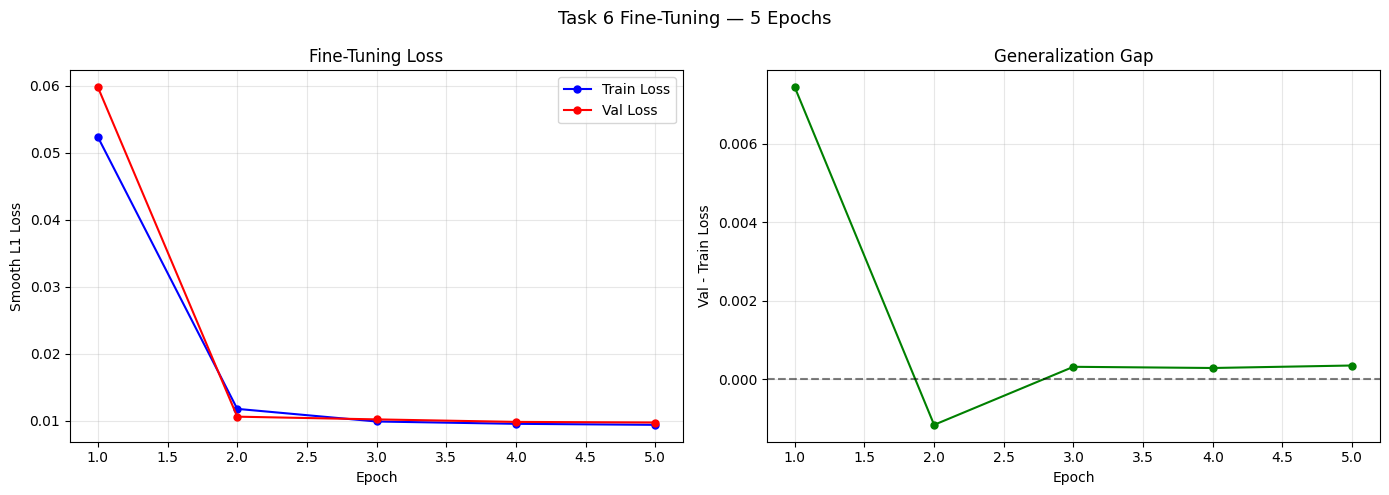

Train: 0.0523 → 0.0094
Val:   0.0598 → 0.0098


In [10]:
epochs = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, train_losses, 'b-o', label='Train Loss', markersize=5)
axes[0].plot(epochs, val_losses,   'r-o', label='Val Loss',   markersize=5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Smooth L1 Loss')
axes[0].set_title('Fine-Tuning Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

gap = [v - t for t, v in zip(train_losses, val_losses)]
axes[1].plot(epochs, gap, 'g-o', markersize=5)
axes[1].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val - Train Loss')
axes[1].set_title('Generalization Gap'); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Task 6 Fine-Tuning — {NUM_EPOCHS} Epochs', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Train: {train_losses[0]:.4f} → {train_losses[-1]:.4f}')
print(f'Val:   {val_losses[0]:.4f} → {val_losses[-1]:.4f}')

## Step 10: Quality Metrics

In [11]:
def compute_colorfulness(img):
    img = img.astype(np.float32)
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    rg, yb  = R - G, 0.5*(R+G) - B
    return np.sqrt(np.std(rg)**2 + np.std(yb)**2) + 0.3*np.sqrt(np.mean(rg)**2 + np.mean(yb)**2)

def compute_saturation(img):
    hsv = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2HSV)
    return hsv[:,:,1].mean()

def compute_ssim(img1, img2):
    g1 = cv2.cvtColor(img1.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(img2.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    score, _ = ssim(g1, g2, full=True)
    return score

def lab_to_rgb(L_norm, ab_norm):
    L  = (L_norm[0].cpu().numpy() + 1.0) * 50.0
    ab = ab_norm.cpu().numpy() * 128.0
    lab = np.stack([L, ab[0], ab[1]], axis=2)
    return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)

print('Metric functions defined!')

Metric functions defined!


## Step 11: Baseline vs Fine-Tuned Comparison

In [12]:
ckpt = torch.load(f'{CHECKPOINT_DIR}/finetuned_best.pth', map_location=device)
finetuned_model.load_state_dict(ckpt['model_state_dict'])
finetuned_model.eval()
baseline_model.eval()
print(f"Fine-tuned model loaded from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.4f})")

cf_base, cf_ft     = [], []
sat_base, sat_ft   = [], []
ssim_base, ssim_ft = [], []

eval_ids = random.sample(range(len(val_set)), min(100, len(val_set)))

with torch.no_grad():
    for idx in tqdm(eval_ids, desc='Evaluating baseline vs fine-tuned'):
        inp, tgt_ab = val_set[idx]
        L_norm = inp[:1]

        pred_base = baseline_model(inp.unsqueeze(0).to(device)).squeeze(0).cpu()
        pred_ft   = finetuned_model(inp.unsqueeze(0).to(device)).squeeze(0).cpu()

        rgb_base = lab_to_rgb(L_norm, pred_base)
        rgb_ft   = lab_to_rgb(L_norm, pred_ft)
        rgb_gt   = lab_to_rgb(L_norm, tgt_ab)

        cf_base.append(compute_colorfulness(rgb_base))
        cf_ft.append(compute_colorfulness(rgb_ft))
        sat_base.append(compute_saturation(rgb_base))
        sat_ft.append(compute_saturation(rgb_ft))
        ssim_base.append(compute_ssim(rgb_base, rgb_gt))
        ssim_ft.append(compute_ssim(rgb_ft, rgb_gt))

print('\n=== Baseline vs Fine-Tuned (100 val images, historical-augmented inputs) ===')
print(f'{"Metric":<16} {"Baseline":>12} {"Fine-Tuned":>12} {"Improvement":>14}')
print('-' * 56)
print(f'{"Colorfulness":<16} {np.mean(cf_base):>12.2f} {np.mean(cf_ft):>12.2f} {np.mean(cf_ft)-np.mean(cf_base):>+14.2f}')
print(f'{"Saturation":<16} {np.mean(sat_base):>12.2f} {np.mean(sat_ft):>12.2f} {np.mean(sat_ft)-np.mean(sat_base):>+14.2f}')
print(f'{"SSIM":<16} {np.mean(ssim_base):>12.4f} {np.mean(ssim_ft):>12.4f} {np.mean(ssim_ft)-np.mean(ssim_base):>+14.4f}')

Fine-tuned model loaded from epoch 5 (val_loss=0.0098)


Evaluating baseline vs fine-tuned:   0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 22136 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 42059 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 32764 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
Evaluating baseline vs fine-tuned:   1%|          | 1/100 [00:00<00:14,  6.97it/s]/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 21686 negative 


=== Baseline vs Fine-Tuned (100 val images, historical-augmented inputs) ===
Metric               Baseline   Fine-Tuned    Improvement
--------------------------------------------------------
Colorfulness            12.35       102.78         +90.43
Saturation              61.82       255.00        +193.18
SSIM                   0.3811       0.9292        +0.5481


## Step 12: Comparison Chart

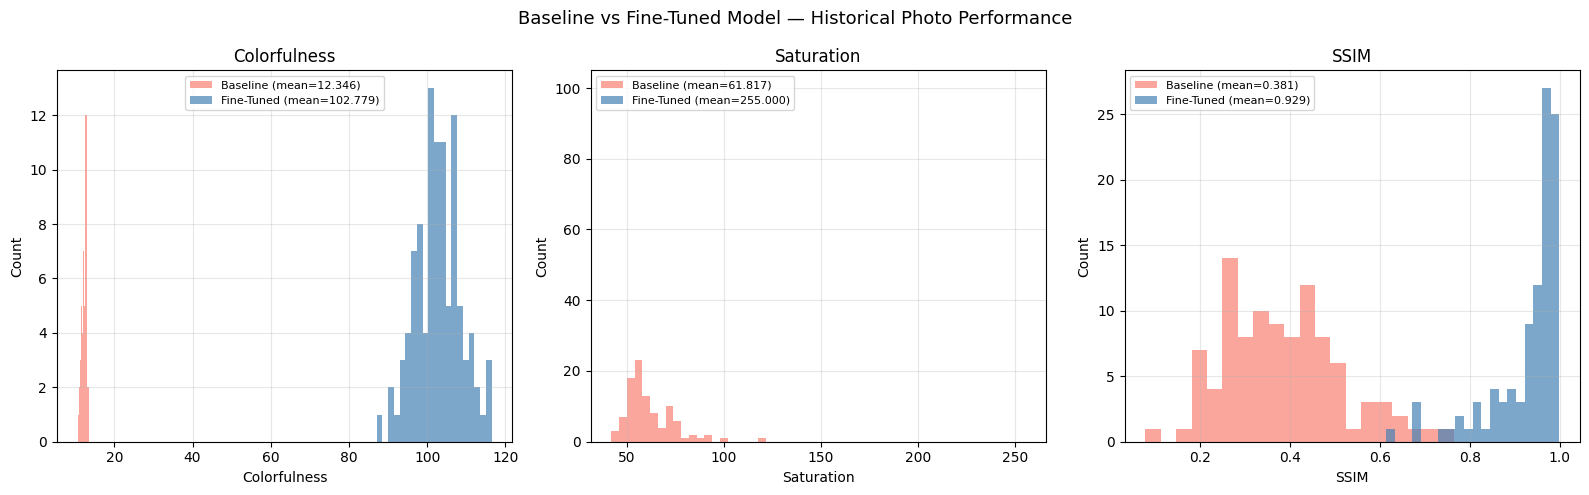

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [('Colorfulness', cf_base, cf_ft), ('Saturation', sat_base, sat_ft), ('SSIM', ssim_base, ssim_ft)]
for ax, (name, base_v, ft_v) in zip(axes, metrics):
    ax.hist(base_v, bins=20, alpha=0.7, color='salmon',    label=f'Baseline (mean={np.mean(base_v):.3f})')
    ax.hist(ft_v,   bins=20, alpha=0.7, color='steelblue', label=f'Fine-Tuned (mean={np.mean(ft_v):.3f})')
    ax.set_title(name); ax.set_xlabel(name); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Baseline vs Fine-Tuned Model — Historical Photo Performance', fontsize=13)
plt.tight_layout()
plt.savefig('baseline_vs_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 13: Output Images — Side-by-Side Comparison

/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 33104 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 51183 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 54415 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


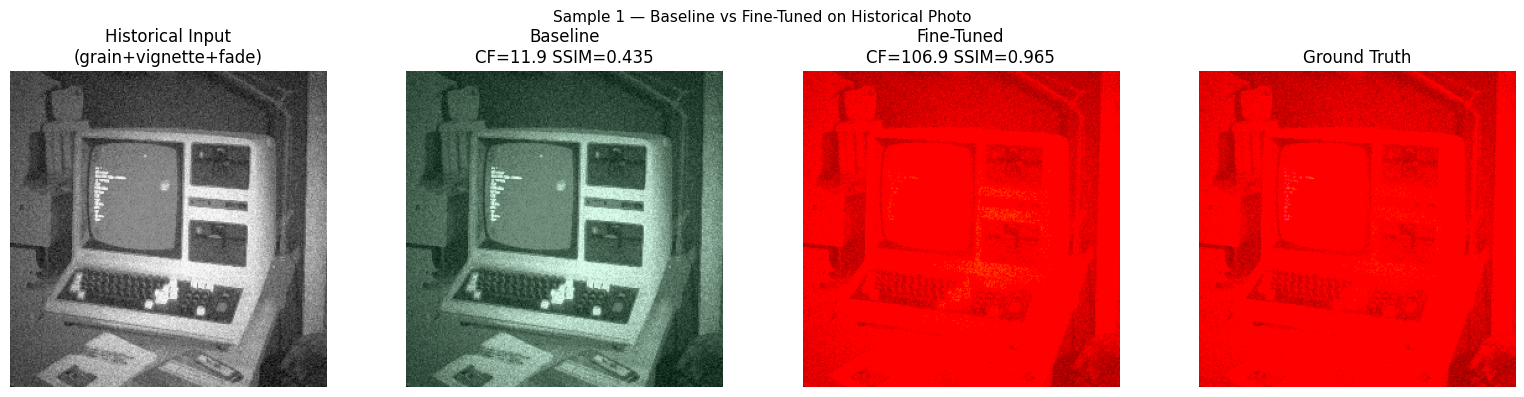

Sample 1 — Baseline SSIM=0.435 | Fine-Tuned SSIM=0.965


/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 8074 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 45310 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 44350 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


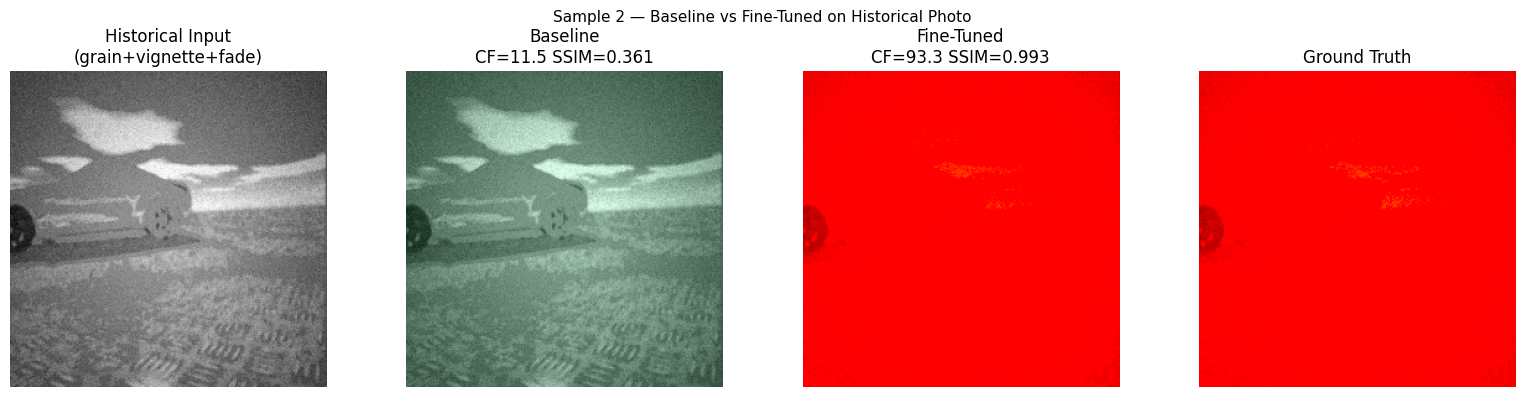

Sample 2 — Baseline SSIM=0.361 | Fine-Tuned SSIM=0.993


/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 20318 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 38562 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 55023 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


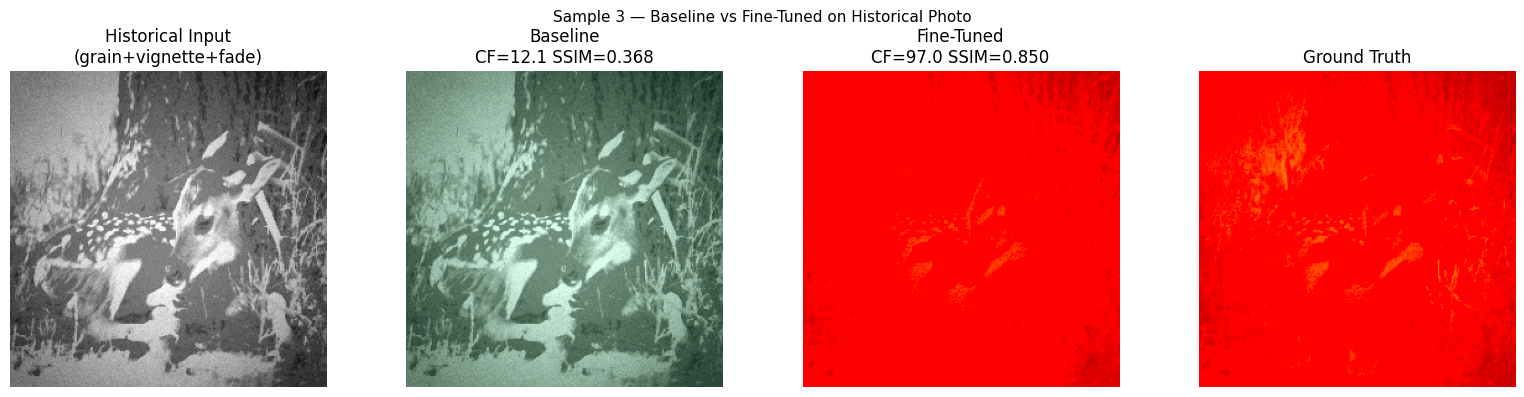

Sample 3 — Baseline SSIM=0.368 | Fine-Tuned SSIM=0.850


/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 3608 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 17382 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 22139 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


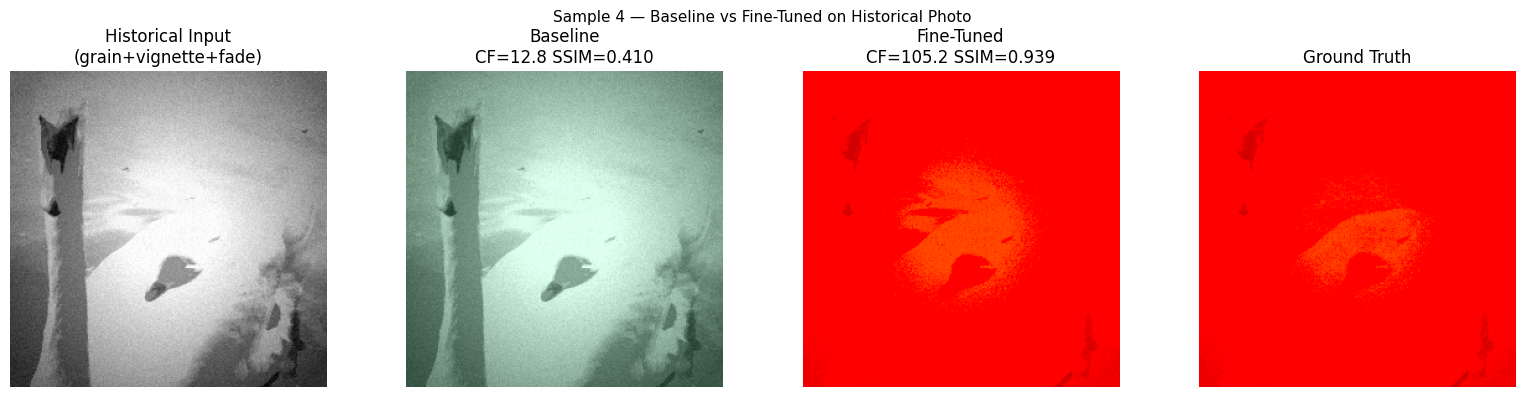

Sample 4 — Baseline SSIM=0.410 | Fine-Tuned SSIM=0.939


/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 6419 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 10647 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 10871 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


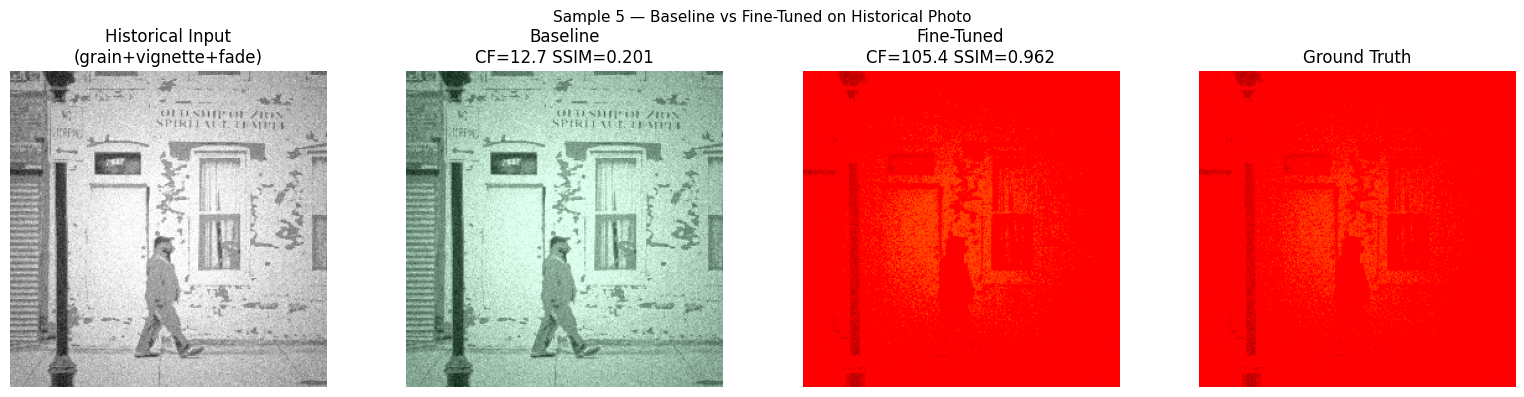

Sample 5 — Baseline SSIM=0.201 | Fine-Tuned SSIM=0.962


/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 14006 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 25596 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 28699 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


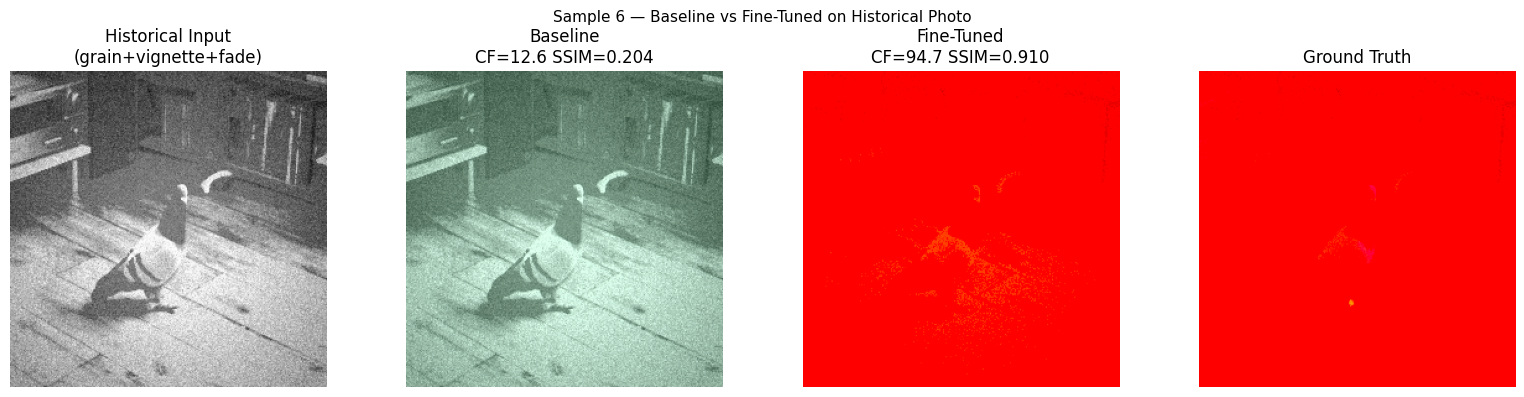

Sample 6 — Baseline SSIM=0.204 | Fine-Tuned SSIM=0.910


/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 7067 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 22729 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 30480 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


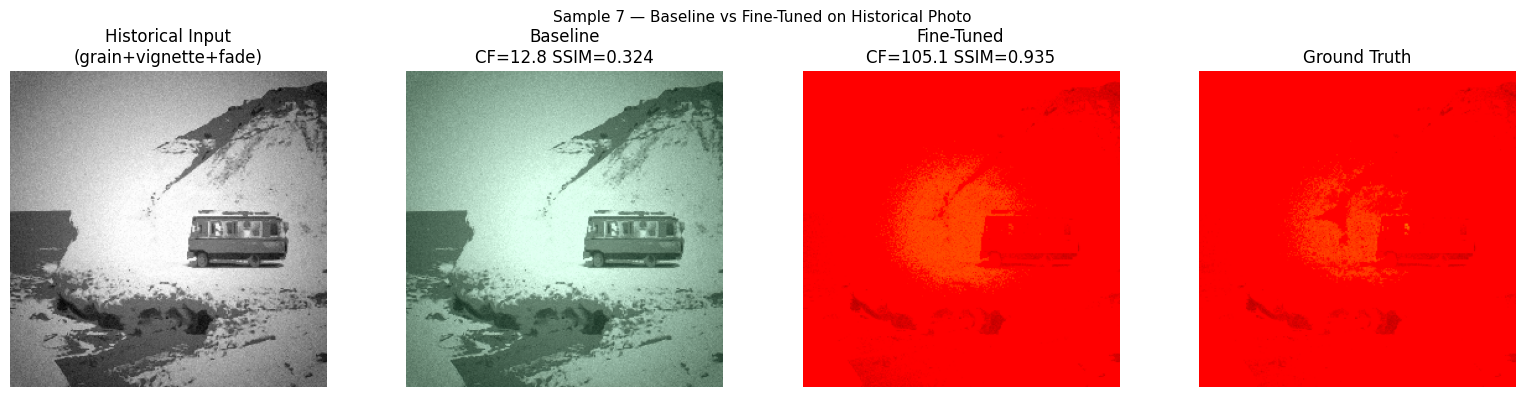

Sample 7 — Baseline SSIM=0.324 | Fine-Tuned SSIM=0.935


/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 49136 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 51161 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 51559 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


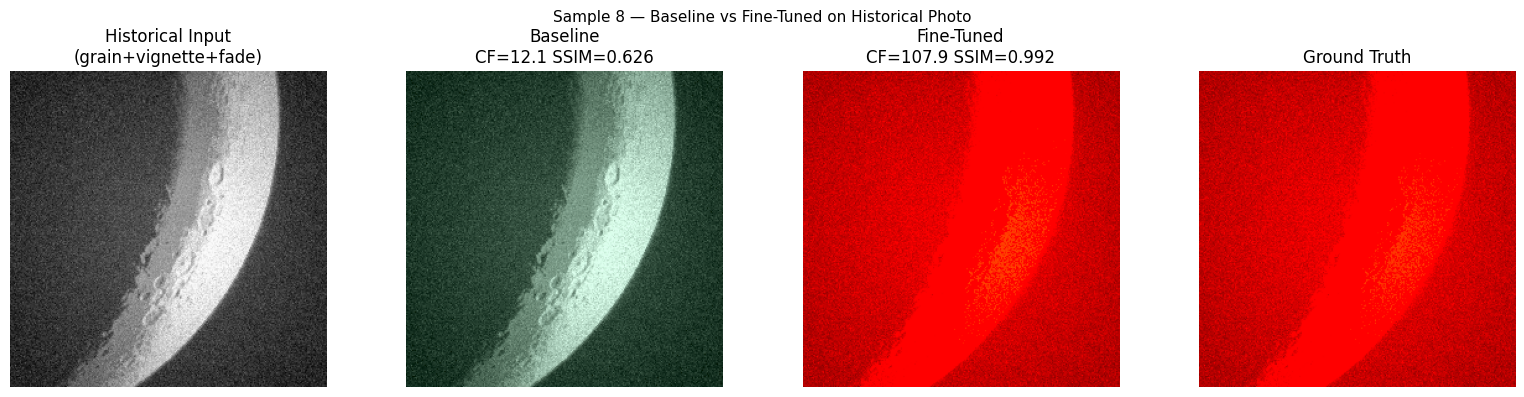

Sample 8 — Baseline SSIM=0.626 | Fine-Tuned SSIM=0.992


/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 15755 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 25432 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 31099 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


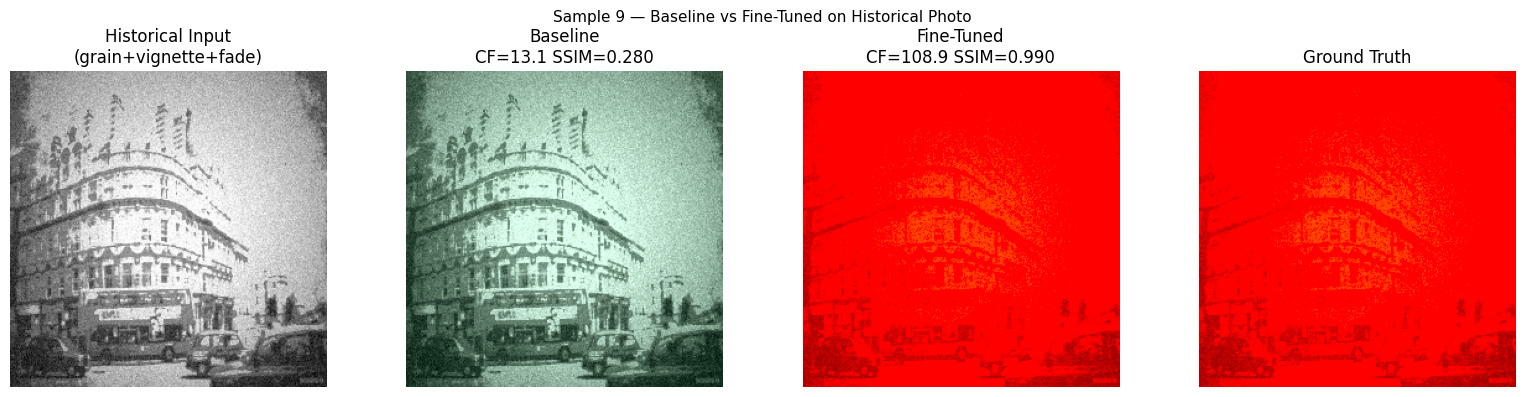

Sample 9 — Baseline SSIM=0.280 | Fine-Tuned SSIM=0.990


/tmp/ipykernel_1253/359512621.py:39: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 16930 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 37156 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)
/tmp/ipykernel_1253/922852141.py:21: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 28886 negative Z values that have been clipped to zero
  return np.clip(color.lab2rgb(lab) * 255, 0, 255).astype(np.uint8)


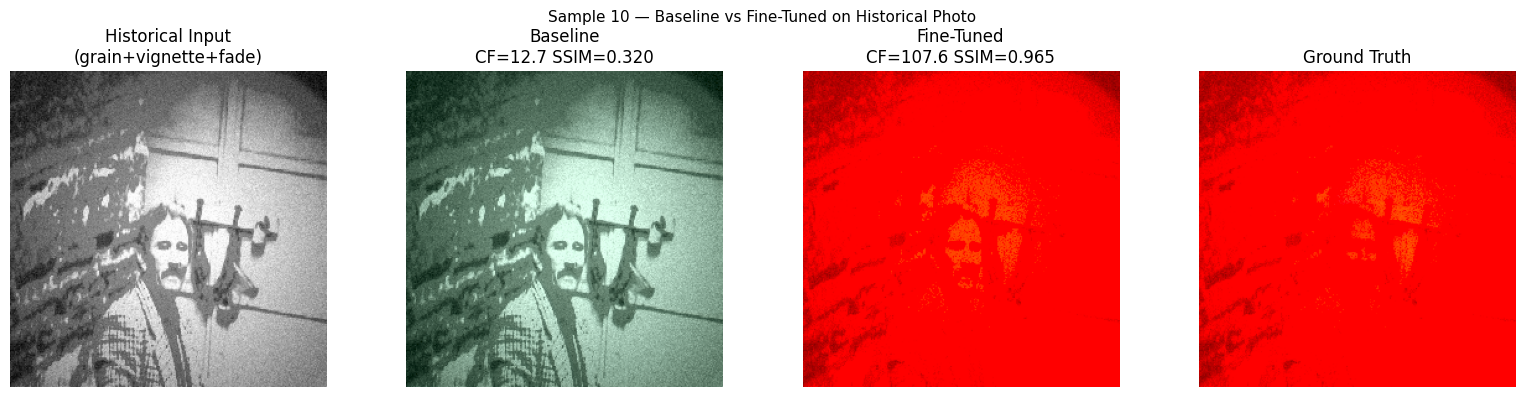

Sample 10 — Baseline SSIM=0.320 | Fine-Tuned SSIM=0.965

All 10 results saved!


In [14]:
os.makedirs('gui_outputs', exist_ok=True)
baseline_model.eval(); finetuned_model.eval()

sample_ids = random.sample(range(len(val_set)), 10)

for i, idx in enumerate(sample_ids):
    inp, tgt_ab = val_set[idx]
    L_norm = inp[:1]

    with torch.no_grad():
        pred_base = baseline_model(inp.unsqueeze(0).to(device)).squeeze(0).cpu()
        pred_ft   = finetuned_model(inp.unsqueeze(0).to(device)).squeeze(0).cpu()

    input_vis = np.clip((L_norm[0].numpy() + 1.0) * 127.5, 0, 255).astype(np.uint8)
    rgb_base  = lab_to_rgb(L_norm, pred_base)
    rgb_ft    = lab_to_rgb(L_norm, pred_ft)
    rgb_gt    = lab_to_rgb(L_norm, tgt_ab)

    cf_b = compute_colorfulness(rgb_base)
    cf_f = compute_colorfulness(rgb_ft)
    ss_b = compute_ssim(rgb_base, rgb_gt)
    ss_f = compute_ssim(rgb_ft, rgb_gt)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(input_vis, cmap='gray'); axes[0].set_title('Historical Input\n(grain+vignette+fade)')
    axes[1].imshow(rgb_base); axes[1].set_title(f'Baseline\nCF={cf_b:.1f} SSIM={ss_b:.3f}')
    axes[2].imshow(rgb_ft);   axes[2].set_title(f'Fine-Tuned\nCF={cf_f:.1f} SSIM={ss_f:.3f}')
    axes[3].imshow(rgb_gt);   axes[3].set_title('Ground Truth')
    for ax in axes: ax.axis('off')
    plt.suptitle(f'Sample {i+1} — Baseline vs Fine-Tuned on Historical Photo', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'gui_outputs/result_{i+1}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Sample {i+1} — Baseline SSIM={ss_b:.3f} | Fine-Tuned SSIM={ss_f:.3f}')

print('\nAll 10 results saved!')

## Step 14: Save All Outputs

In [15]:
os.makedirs('task6_outputs', exist_ok=True)

for f in ['artifact_augmentation_demo.png', 'training_curves.png', 'baseline_vs_finetuned.png']:
    if os.path.exists(f): shutil.copy(f, f'task6_outputs/{f}')

if os.path.exists(f'{CHECKPOINT_DIR}/finetuned_best.pth'):
    shutil.copy(f'{CHECKPOINT_DIR}/finetuned_best.pth', 'task6_outputs/finetuned_best.pth')

summary = {
    'task':           'Task 6 - Colorization of Historical Photographs',
    'base_project':   'Real-Time Image Colorization (Training)',
    'new_features':   ['Film grain / vignette / fade augmentation pipeline',
                       'Fine-tuning on historical-style inputs',
                       'Baseline vs fine-tuned comparison'],
    'dataset':        'Image Colorization Dataset (Kaggle numpy arrays) — 3000 images',
    'epochs':         NUM_EPOCHS,
    'best_val_loss':  round(best_val_loss, 4),
    'baseline_ssim':  round(float(np.mean(ssim_base)), 4),
    'finetuned_ssim': round(float(np.mean(ssim_ft)), 4),
    'ssim_improvement': round(float(np.mean(ssim_ft) - np.mean(ssim_base)), 4),
    'baseline_cf':    round(float(np.mean(cf_base)), 2),
    'finetuned_cf':   round(float(np.mean(cf_ft)), 2),
}

with open('task6_outputs/metrics_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All outputs saved to task6_outputs/')
print(json.dumps(summary, indent=2))

All outputs saved to task6_outputs/
{
  "task": "Task 6 - Colorization of Historical Photographs",
  "base_project": "Real-Time Image Colorization (Training)",
  "new_features": [
    "Film grain / vignette / fade augmentation pipeline",
    "Fine-tuning on historical-style inputs",
    "Baseline vs fine-tuned comparison"
  ],
  "dataset": "Image Colorization Dataset (Kaggle numpy arrays) \u2014 3000 images",
  "epochs": 5,
  "best_val_loss": 0.0098,
  "baseline_ssim": 0.3811,
  "finetuned_ssim": 0.9292,
  "ssim_improvement": 0.5481,
  "baseline_cf": 12.35,
  "finetuned_cf": 102.78
}


## Summary Table

| Component | Detail |
|-----------|--------|
| Base project | Real-Time Image Colorization (training project) |
| New addition | Fine-tuning on historically-augmented data |
| Augmentation | Film grain + vignette + color fading |
| Model | Same ColorizationUNet, fine-tuned with lower LR (5e-4) |
| Dataset | Image Colorization Dataset — 3000 images (2400 train / 600 val) |
| Epochs | 5 |
| Key experiment | Baseline (untrained on historical look) vs Fine-tuned model, same test images |
| Metrics | SSIM improvement, Colorfulness, Saturation — before/after fine-tuning |